# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ Hamiltonians - check states

Created: 15-07-2026

Objectives:
* Check the states that were saved [here](../../save_states/z2_f_x_z2_t_hamiltonians.ipynb).

# Imports

In [1]:
from time import time

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from itertools import product, combinations_with_replacement

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from humanize import naturalsize

In [9]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Import states

In [10]:
triv_cocycle_data = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')
    for i in range(0, 101, 5)
]

In [11]:
nontriv_cocycle_data = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')
    for i in range(0, 101, 5)
]

In [12]:
len(triv_cocycle_data), len(nontriv_cocycle_data)

(21, 21)

In [13]:
triv_groundstates = [
    x['psi'] for x in triv_cocycle_data
]

nontriv_groundstates = [
    x['psi'] for x in nontriv_cocycle_data
]

In [14]:
len(triv_groundstates), len(nontriv_groundstates)

(21, 21)

# Definitions

In [15]:
L = 10

In [16]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [17]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
	      0.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 1>  1023 
	      1.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 0>  1022 
	      2.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 1>  1021 
	      3.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 0>  1020 
	      4.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 1>  1019 
	      5.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 0>  1018 
	      6.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 1>  1017 
	      7.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 0>  1016 
	      8.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 1>  1015 
	      9.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 0>  1014 
	     10.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 1>  1013 
	     11.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 0>  1012 
	     12.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 0 1 1>  1011 
	     13.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1

# Analysis

## Energies

In [18]:
triv_energies = [x['energy'] for x in triv_cocycle_data]

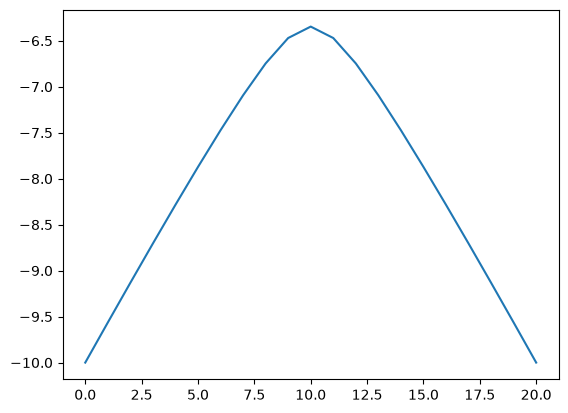

In [19]:
plt.plot(triv_energies)

In [20]:
nontriv_energies = [x['energy'] for x in nontriv_cocycle_data]

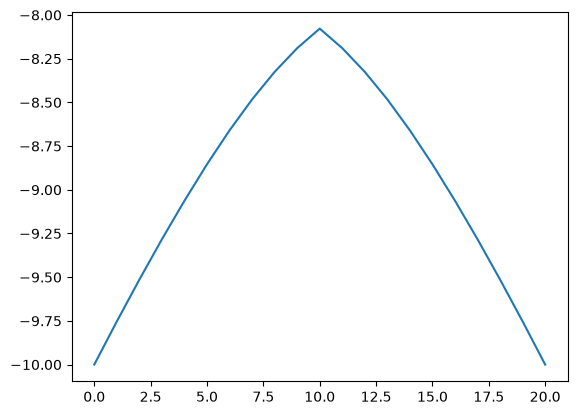

In [21]:
plt.plot(nontriv_energies)

## Check $T=XK$ symmetry

In [22]:
x_sym = quantum_operator(
    {"x": [["x"*L + "|", [[1, *list(range(L))]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!


/tmp/ipykernel_26467/1830159187.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  x_sym = quantum_operator(
/tmp/ipykernel_26467/1830159187.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  x_sym = quantum_operator(


In [23]:
psi = triv_cocycle_data[0]['psi']

In [24]:
psi.shape

(1048576, 1)

In [25]:
naturalsize(psi.nbytes)

'16.8 MB'

In [26]:
sym_psi = psi.conj()

In [27]:
np.sum(sym_psi.conj()*sym_psi)

np.complex128(1.0000000000000002-6.06791674103523e-18j)

In [28]:
np.sum(psi.conj()*psi)

np.complex128(1.0000000000000002+6.06791674103523e-18j)

In [29]:
np.abs(np.sum(sym_psi.conj()*psi))

np.float64(1.0000000000000002)

## Expectation values

In [30]:
one_site_paulis = [
    quantum_operator(
        {s: [[f"{s}|" , [[1, 0]]]]},
        basis=basis,
        dtype=np.complex128
    )
    for s in "xyz"
]

Hermiticity check passed!


/tmp/ipykernel_26467/4294405670.py:2: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/tmp/ipykernel_26467/4294405670.py:2: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


Hermiticity check passed!
Hermiticity check passed!


In [31]:
one_site_fermion_occupation = quantum_operator(
    {"n": [["|n" , [[1, 0]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!


/tmp/ipykernel_26467/2974233378.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  one_site_fermion_occupation = quantum_operator(
/tmp/ipykernel_26467/2974233378.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  one_site_fermion_occupation = quantum_operator(


In [32]:
triv_groundstates = [
    x['psi'] for x in triv_cocycle_data
]

nontriv_groundstates = [
    x['psi'] for x in nontriv_cocycle_data
]

In [33]:
triv_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in triv_groundstates]
    for op in one_site_paulis
])

nontriv_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in nontriv_groundstates]
    for op in one_site_paulis
])

In [34]:
np.round(triv_pauli_expectations, 3)

array([[[ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [ 0.02 +0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [ 0.   -0.j]],

       [[-0.   -0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.202+0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   +0.j]],

       [[ 1.   +0.j],
        [ 1.   +0.j],
        [ 0.999+0.j],
      

In [35]:
parameters = np.linspace(0, 1, 21)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


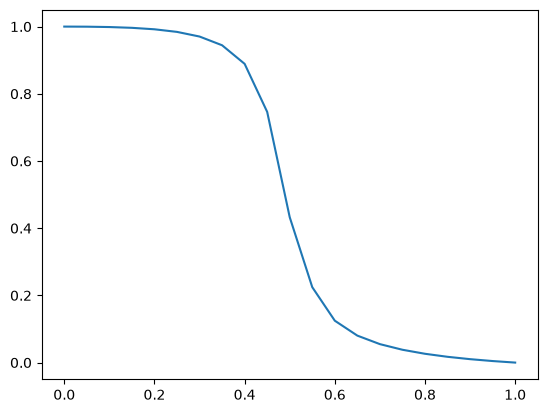

In [36]:
plt.plot(parameters, triv_pauli_expectations[2])

In [37]:
np.round(nontriv_pauli_expectations, 3)

array([[[-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [-0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j]],

       [[-0.+0.j],
        [ 0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [-0.+0.j],
        [ 0.-0.j]],

       [[ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        

All vanishing expectations is odd...

In [38]:
triv_fermion_occupations = np.array([
    one_site_fermion_occupation.expt_value(psi) for psi in triv_groundstates
])

nontriv_fermion_occupations = np.array([
    one_site_fermion_occupation.expt_value(psi) for psi in nontriv_groundstates
])

In [39]:
triv_fermion_occupations

array([[2.05532567e-31+0.j],
       [4.06836856e-05+0.j],
       [1.93433384e-04+0.j],
       [5.26435342e-04+0.j],
       [1.15694439e-03+0.j],
       [2.29872227e-03+0.j],
       [4.37630098e-03+0.j],
       [8.36038277e-03+0.j],
       [1.71082571e-02+0.j],
       [4.19340516e-02+0.j],
       [1.24299678e-01+0.j],
       [2.60409257e-01+0.j],
       [3.51704383e-01+0.j],
       [3.98416618e-01+0.j],
       [4.27367287e-01+0.j],
       [4.47798310e-01+0.j],
       [4.63215765e-01+0.j],
       [4.75330239e-01+0.j],
       [4.85121728e-01+0.j],
       [4.93207367e-01+0.j],
       [5.00000000e-01+0.j]])

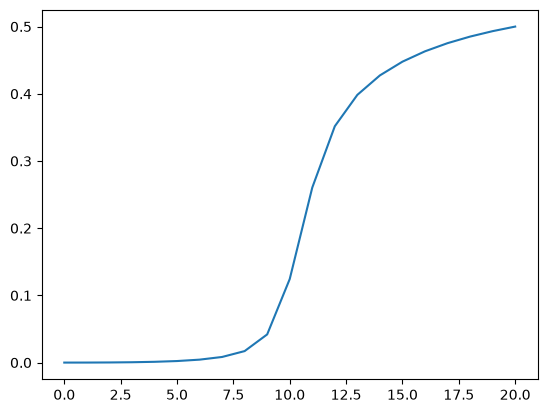

In [40]:
plt.plot(triv_fermion_occupations)

In [41]:
nontriv_fermion_occupations

array([[0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.53760871+0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j]])

In [57]:
two_site_paulis = [
    quantum_operator(
        {s: [[f"{s+s}|" , [[1, 0, 1]]]]},
        basis=basis,
        dtype=np.complex128
    )
    for s in "xyz"
]

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


/tmp/ipykernel_26467/3625545787.py:2: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/tmp/ipykernel_26467/3625545787.py:2: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


In [58]:
triv_two_site_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in triv_groundstates]
    for op in two_site_paulis
])

nontriv_two_site_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in nontriv_groundstates]
    for op in two_site_paulis
])

In [59]:
np.round(triv_two_site_pauli_expectations, 3)

array([[[ 0.   +0.j],
        [-0.013+0.j],
        [-0.029+0.j],
        [-0.046+0.j],
        [-0.067+0.j],
        [-0.09 +0.j],
        [-0.117-0.j],
        [-0.147+0.j],
        [-0.173+0.j],
        [-0.164-0.j],
        [-0.05 +0.j],
        [-0.017+0.j],
        [-0.006-0.j],
        [-0.003+0.j],
        [-0.001-0.j],
        [-0.001-0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j]],

       [[-0.   -0.j],
        [ 0.014-0.j],
        [ 0.029-0.j],
        [ 0.048-0.j],
        [ 0.071-0.j],
        [ 0.1  -0.j],
        [ 0.137+0.j],
        [ 0.186-0.j],
        [ 0.262+0.j],
        [ 0.395+0.j],
        [ 0.529-0.j],
        [ 0.395-0.j],
        [ 0.262-0.j],
        [ 0.186+0.j],
        [ 0.137-0.j],
        [ 0.1  -0.j],
        [ 0.071+0.j],
        [ 0.048-0.j],
        [ 0.029-0.j],
        [ 0.014-0.j],
        [ 0.   +0.j]],

       [[ 1.   +0.j],
        [ 1.   +0.j],
        [ 0.998+0.j],
      

In [60]:
np.round(nontriv_two_site_pauli_expectations, 3)

array([[[-0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [ 0.   -0.j]],

       [[-0.   +0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [-0.075+0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [-0.   +0.j]],

       [[ 0.   +0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
      

Are the nontrivial states just wrong?

In [61]:
overlaps = np.zeros((21, 21))

In [62]:
overlaps.shape

(21, 21)

In [63]:
for i, j in tqdm(combinations_with_replacement(range(21), 2)):
    overlap = np.abs(np.sum(nontriv_groundstates[i].conj() * nontriv_groundstates[j]))
    overlaps[i,j] = overlap
    overlaps[j,i] = overlap

231it [00:01, 163.73it/s]


In [64]:
np.round(overlaps, 3)

array([[1.   , 0.999, 0.996, 0.99 , 0.981, 0.966, 0.944, 0.915, 0.877,
        0.83 , 0.706, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.999, 1.   , 0.999, 0.995, 0.988, 0.976, 0.957, 0.931, 0.895,
        0.851, 0.728, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.996, 0.999, 1.   , 0.999, 0.994, 0.985, 0.969, 0.946, 0.914,
        0.873, 0.75 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.99 , 0.995, 0.999, 1.   , 0.998, 0.992, 0.981, 0.961, 0.933,
        0.896, 0.775, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.981, 0.988, 0.994, 0.998, 1.   , 0.998, 0.99 , 0.976, 0.952,
        0.919, 0.8  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.966, 0.976, 0.985, 0.992, 0.998, 1.   , 0.997, 0.988, 0.97 ,
        0.943, 0.826, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   

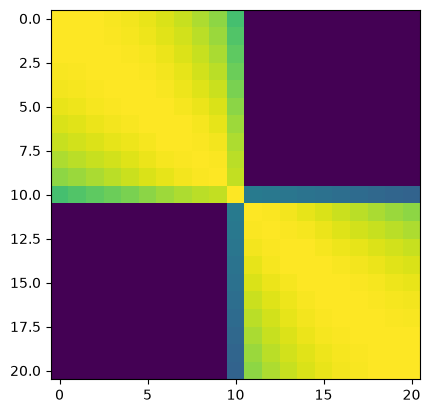

In [65]:
plt.imshow(overlaps)

Fascinating! Clear sign of a phase transition, I haven't seen this before. So something is changing!

## Check entanglement via $\rho$

In [66]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(2, 16)),
    'left_defect_sites': [2, 3],
    'right_defect_sites': [14, 15],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [67]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [68]:
def get_left_right_schmidt_values(quspin_psi, domains_dict):
    inds = (
        [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
        + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
    )

    qt_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    rho_lr = (
        rho
        .reindex({f'k{i}': f'b{i}' for i in central_sites})
        .contract()
    )

    left_defect_inds = (
        [f'k{i}' for i in domains_dict['left_defect_sites']]
        + [f'b{i}' for i in domains_dict['left_defect_sites']]
    )

    split_rho_lr = qtn.tensor_core.tensor_split(
        rho_lr,
        left_inds=left_defect_inds,
        absorb=None,
        bond_ind='vH'
    )

    out = split_rho_lr.tensors[1].data

    return out

In [69]:
triv_schmidt_vals = [
    get_left_right_schmidt_values(psi, domains_dict)
    for psi in triv_groundstates
]

nontriv_schmidt_vals = [
    get_left_right_schmidt_values(psi, domains_dict)
    for psi in nontriv_groundstates
]

In [70]:
triv_schmidt_vals

[array([1.]),
 array([9.99670845e-01, 3.82668570e-05, 1.20550243e-05, 3.99053549e-09,
        3.99053548e-09, 7.13997900e-10, 7.13997891e-10, 6.12759998e-10]),
 array([9.98443558e-01, 2.05103551e-04, 6.06579464e-05, 9.07639129e-08,
        9.07639129e-08, 1.76647107e-08, 1.64472873e-08, 1.64472873e-08]),
 array([9.95794588e-01, 6.37789968e-04, 1.75501578e-04, 6.74084558e-07,
        6.74084558e-07, 1.69315671e-07, 1.24067372e-07, 1.24067372e-07,
        1.17980875e-10]),
 array([9.90847547e-01, 1.62813231e-03, 4.11670462e-04, 3.24341691e-06,
        3.24341691e-06, 1.08145972e-06, 6.09130584e-07, 6.09130584e-07,
        3.56622772e-09, 1.29470977e-09, 5.54926910e-10, 5.54926910e-10,
        4.72544722e-10, 4.72544722e-10]),
 array([9.82059643e-01, 3.83475233e-03, 8.74579528e-04, 1.25965545e-05,
        1.25965545e-05, 5.80790071e-06, 2.43324053e-06, 2.43324053e-06,
        3.28164653e-08, 1.00975360e-08, 4.23856904e-09, 4.23856904e-09,
        1.70204834e-09, 1.70204834e-09]),
 array([

In [71]:
nontriv_schmidt_vals

[array([0.25]),
 array([2.50000000e-01, 2.48247134e-04, 2.48247134e-04]),
 array([0.25      , 0.00104914, 0.00104914]),
 array([0.25      , 0.00248364, 0.00248364]),
 array([0.25      , 0.00461523, 0.00461523]),
 array([0.25      , 0.00746391, 0.00746391]),
 array([0.25      , 0.01096843, 0.01096843]),
 array([0.25      , 0.01494373, 0.01494373]),
 array([0.25      , 0.01905672, 0.01905672]),
 array([0.25     , 0.0228574, 0.0228574]),
 array([0.2514065 , 0.04113268, 0.03812399, 0.0014065 ]),
 array([0.25     , 0.0228574, 0.0228574]),
 array([0.25      , 0.01905672, 0.01905672]),
 array([0.25      , 0.01494373, 0.01494373]),
 array([0.25      , 0.01096843, 0.01096843]),
 array([0.25      , 0.00746391, 0.00746391]),
 array([0.25      , 0.00461523, 0.00461523]),
 array([0.25      , 0.00248364, 0.00248364]),
 array([0.25      , 0.00104914, 0.00104914]),
 array([2.50000000e-01, 2.48247134e-04, 2.48247134e-04]),
 array([0.25])]

Pretty much as expected...

# Conclusion
More or less ok, but weird things happening with expectations.